# STEP 1: PROBLEMS_UNDERSTANDING 


- Loại bài toán: Clustering (Phân cụm - Học không giám sát).

- Features (Đặc trưng đầu vào): * Dữ liệu gốc: Thu nhập, tuổi, giới tính, loại thẻ (Debit/Credit), số tiền giao dịch, mã ngành hàng (MCC).

    + Dữ liệu phái sinh (Cốt lõi): Chỉ số RFM (Độ gần đây, Tần suất, Tổng tiền) và Tỷ lệ chi tiêu bằng thẻ Debit.

- Target (Mục tiêu dự đoán): Đầu ra là một Nhãn cụm (Cluster Label) do máy tự gán (Ví dụ: Nhóm 0, Nhóm 1...) để từ đó ta phân tích ra đâu là nhóm "VIP dùng Debit".

- Metric (Thước đo đánh giá):Chấm điểm bằng:

    + Silhouette Score: Đo độ sắc nét và tách biệt giữa các cụm.

    + Inertia (WCSS): Dùng vẽ biểu đồ Elbow để chọn số lượng cụm (K) tối ưu.

    + Business Logic: Đánh giá bằng mắt thường xem các cụm chia ra có ý nghĩa kinh doanh thực tế hay không.

# STEP 2: DATA UNDERSTANDING 

# IMPORT CÁC THƯ VIỆN CẦN THIẾT 


In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore') # Tắt các cảnh báo lặt vặt để code gọn gàng
import matplotlib.pyplot as plt
import seaborn as sns



# ĐỌC DỮ LIỆU VÀO 

In [2]:
print(" Đang tải dữ liệu từ Excel...")
try:
    df_users = pd.read_excel(r'C:\Users\Admin\Desktop\Foundation_Project\dataset\users_data.xlsx')
    df_cards = pd.read_excel(r'C:\Users\Admin\Desktop\Foundation_Project\dataset\cards_data.xlsx')
    df_transactions = pd.read_excel(r'C:\Users\Admin\Desktop\Foundation_Project\dataset\transactions_data.xlsx')
    df_mcc = pd.read_excel(r'C:\Users\Admin\Desktop\Foundation_Project\dataset\mcc_codes.xlsx')
    print("Ngày giao dịch đầu tiên:", df_transactions['date'].min())
    print("Ngày giao dịch cuối cùng:", df_transactions['date'].max())
    print("-> Tải dữ liệu thành công!\n")
except Exception as e:
    print(f"-> Lỗi khi tải dữ liệu: {e}")
    print("Vui lòng kiểm tra lại đường dẫn file.")


 Đang tải dữ liệu từ Excel...
Ngày giao dịch đầu tiên: 2022-01-01 01:43:00
Ngày giao dịch cuối cùng: 2024-10-31 23:06:00
-> Tải dữ liệu thành công!



# KIỂM TRA TỔNG QUAN DỮ LIỆU 

In [3]:
datasets = {
    "1. USERS DATA": df_users,
    "2. CARDS DATA": df_cards,
    "3. TRANSACTIONS DATA": df_transactions,
    "4. MCC CODES": df_mcc
}

print(" TỔNG QUAN KÍCH THƯỚC DỮ LIỆU (Số dòng, Số cột):")
for name, df in datasets.items():
    print(f"- {name}: {df.shape}")

 TỔNG QUAN KÍCH THƯỚC DỮ LIỆU (Số dòng, Số cột):
- 1. USERS DATA: (2000, 14)
- 2. CARDS DATA: (6146, 12)
- 3. TRANSACTIONS DATA: (157224, 12)
- 4. MCC CODES: (109, 2)


# XEM TÊN CÁC CỘT CỦA MỖI BẢNG 

In [4]:

print(" DANH SÁCH TÊN CỘT CỦA CÁC BẢNG DỮ LIỆU:\n")

for name, df in datasets.items():
    print(f" BẢNG {name} ({len(df.columns)} cột):")
    # Lấy danh sách tên cột, chuyển thành chuỗi và ngăn cách bằng dấu ' | '
    columns_list = df.columns.tolist()
    print(" | ".join(columns_list))
    print("-" * 70)

 DANH SÁCH TÊN CỘT CỦA CÁC BẢNG DỮ LIỆU:

 BẢNG 1. USERS DATA (14 cột):
id | current_age | retirement_age | birth_year | birth_month | gender | address | latitude | longitude | per_capita_income | yearly_income | total_debt | credit_score | num_credit_cards
----------------------------------------------------------------------
 BẢNG 2. CARDS DATA (12 cột):
id | client_id | card_brand | card_type | card_number | expires | cvv | has_chip | num_cards_issued | credit_limit | acct_open_date | year_pin_last_changed
----------------------------------------------------------------------
 BẢNG 3. TRANSACTIONS DATA (12 cột):
id | date | client_id | card_id | amount | use_chip | merchant_id | merchant_city | merchant_state | zip | mcc | errors
----------------------------------------------------------------------
 BẢNG 4. MCC CODES (2 cột):
mcc_id | Description
----------------------------------------------------------------------


In [5]:
# ==========================================
# KIỂM TRA INFO VÀ DESCRIBE HÀNG LOẠT
# ==========================================
print("=== BÁO CÁO CẤU TRÚC VÀ THỐNG KÊ MÔ TẢ ===\n")

for name, df in datasets.items():
    print(f" ================= BẢNG {name} =================")
    
    # 1. Kiểm tra cấu trúc dữ liệu (INFO)
    print("\n[1] THÔNG TIN CẤU TRÚC (INFO):")
    # Sử dụng verbose=False nếu bạn chỉ muốn xem tóm tắt, nhưng ở đây ta xem chi tiết
    df.info() 
    
    # 2. Kiểm tra thống kê mô tả (DESCRIBE)
    # Tự động chọn các cột số và làm tròn 2 chữ số thập phân cho dễ đọc
    print("\n[2] THỐNG KÊ MÔ TẢ (DESCRIBE):")
    try:
        display(df.describe().round(2))
    except ValueError:
        print(" -> Bảng này không có dữ liệu số học để thống kê.")
        
    print("\n" + "="*60 + "\n")

=== BÁO CÁO CẤU TRÚC VÀ THỐNG KÊ MÔ TẢ ===

 ================= BẢNG 1. USERS DATA =================

[1] THÔNG TIN CẤU TRÚC (INFO):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 2000 non-null   int64  
 1   current_age        2000 non-null   int64  
 2   retirement_age     2000 non-null   int64  
 3   birth_year         2000 non-null   int64  
 4   birth_month        2000 non-null   int64  
 5   gender             2000 non-null   object 
 6   address            2000 non-null   object 
 7   latitude           2000 non-null   object 
 8   longitude          2000 non-null   float64
 9   per_capita_income  2000 non-null   object 
 10  yearly_income      2000 non-null   object 
 11  total_debt         2000 non-null   object 
 12  credit_score       2000 non-null   int64  
 13  num_credit_cards   2000 non-null   i

,id,current_age,retirement_age,birth_year,birth_month,longitude,credit_score,num_credit_cards
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,999.50,45.39,66.24,1973.80,6.44,-91.55,709.73,3.07
std,577.49,18.41,3.63,18.42,3.57,16.28,67.22,1.64
min,0.00,18.00,50.00,1918.00,1.00,-159.41,480.00,1.00
25%,499.75,30.00,65.00,1961.00,3.00,-97.40,681.00,2.00
50%,999.50,44.00,66.00,1975.00,7.00,-86.44,711.50,3.00
75%,1499.25,58.00,68.00,1989.00,10.00,-80.13,753.00,4.00
max,1999.00,101.00,79.00,2002.00,12.00,-68.67,850.00,9.00




 ================= BẢNG 2. CARDS DATA =================

[1] THÔNG TIN CẤU TRÚC (INFO):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     6146 non-null   int64         
 1   client_id              6146 non-null   int64         
 2   card_brand             6146 non-null   object        
 3   card_type              6146 non-null   object        
 4   card_number            6146 non-null   int64         
 5   expires                6146 non-null   datetime64[ns]
 6   cvv                    6146 non-null   int64         
 7   has_chip               6146 non-null   object        
 8   num_cards_issued       6146 non-null   int64         
 9   credit_limit           6146 non-null   object        
 10  acct_open_date         6146 non-null   datetime64[ns]
 11  year_pin_last_changed  6146 non

,id,client_id,card_number,expires,cvv,num_cards_issued,acct_open_date,year_pin_last_changed
count,6146.00,6146.00,6.146000e+03,6146,6146.00,6146.00,6146,6146.00
mean,3072.50,994.94,4.820426e+15,2020-10-08 06:30:06.443215360,506.22,1.50,2011-01-15 12:55:31.727953152,2013.44
min,0.00,0.00,3.001055e+14,1997-07-01 00:00:00,0.00,1.00,1991-01-01 00:00:00,2002.00
25%,1536.25,492.25,4.486365e+15,2020-02-01 00:00:00,257.00,1.00,2006-10-01 00:00:00,2010.00
50%,3072.50,992.00,5.108957e+15,2021-09-01 00:00:00,516.50,1.00,2010-02-15 00:00:00,2013.00
75%,4608.75,1495.00,5.585237e+15,2023-05-01 00:00:00,756.00,2.00,2016-05-01 00:00:00,2017.00
max,6145.00,1999.00,6.997197e+15,2024-12-01 00:00:00,999.00,3.00,2020-02-01 00:00:00,2020.00
std,1774.34,578.61,1.328582e+15,NaN,289.43,0.52,NaN,4.27




 ================= BẢNG 3. TRANSACTIONS DATA =================

[1] THÔNG TIN CẤU TRÚC (INFO):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157224 entries, 0 to 157223
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   id              157224 non-null  int64         
 1   date            157224 non-null  datetime64[ns]
 2   client_id       157224 non-null  int64         
 3   card_id         157224 non-null  int64         
 4   amount          157224 non-null  float64       
 5   use_chip        157224 non-null  object        
 6   merchant_id     157224 non-null  int64         
 7   merchant_city   157224 non-null  object        
 8   merchant_state  139303 non-null  object        
 9   zip             138118 non-null  float64       
 10  mcc             157224 non-null  int64         
 11  errors          2738 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(5), o

,id,date,client_id,card_id,amount,merchant_id,zip,mcc
count,157224.00,157224,157224.00,157224.00,157224.00,157224.00,138118.00,157224.00
mean,21319932.06,2023-06-01 22:41:27.713326080,244.47,3472.71,43.72,47876.18,52374.56,5581.75
min,18881583.00,2022-01-01 01:43:00,0.00,19.00,-500.00,37.00,1010.00,1711.00
25%,20099289.25,2022-09-15 18:47:45,114.00,2426.00,8.59,25887.00,28657.00,5300.00
50%,21312982.50,2023-05-31 11:01:30,235.00,3581.00,31.14,45453.00,48235.00,5499.00
75%,22538005.50,2024-02-14 19:34:30,373.00,4841.00,66.23,68671.00,78413.00,5812.00
max,23761821.00,2024-10-31 23:06:00,497.00,6133.00,1911.54,100340.00,99829.00,9402.00
std,1409058.33,NaN,147.29,1638.19,81.09,26009.16,29720.52,876.44




 ================= BẢNG 4. MCC CODES =================

[1] THÔNG TIN CẤU TRÚC (INFO):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   mcc_id       109 non-null    int64 
 1   Description  109 non-null    object
dtypes: int64(1), object(1)
memory usage: 1.8+ KB

[2] THỐNG KÊ MÔ TẢ (DESCRIBE):


,mcc_id
count,109.00
mean,5311.17
std,1747.76
min,1711.00
25%,3684.00
50%,5310.00
75%,5977.00
max,9402.00


# XỬ LÝ KIỂU DỮ LIỆU BẢNG USERS

In [9]:
# ==========================================
# LÀM SẠCH VÀ ÉP KIỂU DỮ LIỆU BẢNG USERS
# ==========================================
print(" Bắt đầu dọn dẹp các cột bị sai Dtype trong bảng USERS...\n")

# 1. Xử lý bộ 3 cột Tiền bạc (Loại bỏ '$', dấu phẩy và ép về float)
money_columns = ['per_capita_income', 'yearly_income', 'total_debt']

for col in money_columns:
    # Biến tất cả thành chuỗi -> Xóa dấu $ -> Xóa dấu phẩy -> Ép kiểu float
    df_users[col] = df_users[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
    # Lệnh to_numeric giúp chuyển thành số, nếu gặp chữ lạ (như N/A) sẽ ép thành giá trị rỗng (NaN)
    df_users[col] = pd.to_numeric(df_users[col], errors='coerce')
    print(f" Đã chuyển đổi cột '{col}' thành kiểu số (float64).")

# 2. Xử lý cột Vĩ độ (latitude)
df_users['latitude'] = pd.to_numeric(df_users['latitude'], errors='coerce')
print(" Đã chuyển đổi cột 'latitude' thành kiểu số (float64).")

print("-" * 50)
print(" KIỂM TRA LẠI DTYPE SAU KHI SỬA:")
print(df_users[['latitude', 'per_capita_income', 'yearly_income', 'total_debt']].dtypes)

 Bắt đầu dọn dẹp các cột bị sai Dtype trong bảng USERS...

 Đã chuyển đổi cột 'per_capita_income' thành kiểu số (float64).
 Đã chuyển đổi cột 'yearly_income' thành kiểu số (float64).
 Đã chuyển đổi cột 'total_debt' thành kiểu số (float64).
 Đã chuyển đổi cột 'latitude' thành kiểu số (float64).
--------------------------------------------------
 KIỂM TRA LẠI DTYPE SAU KHI SỬA:
latitude             float64
per_capita_income      int64
yearly_income          int64
total_debt             int64
dtype: object


# XỬ LÝ DỮ LIỆU BẢNG CARDS 

In [10]:
# ==========================================
# LÀM SẠCH VÀ ÉP KIỂU CỘT CREDIT_LIMIT (BẢNG CARDS)
# ==========================================
print("Bắt đầu dọn dẹp cột credit_limit trong bảng CARDS...\n")

# Ép thành chuỗi -> Xóa ký hiệu $ -> Xóa dấu phẩy -> Ép kiểu float
df_cards['credit_limit'] = df_cards['credit_limit'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)

# Chuyển thành số thực
df_cards['credit_limit'] = pd.to_numeric(df_cards['credit_limit'], errors='coerce')

print("Đã chuyển đổi cột 'credit_limit' thành kiểu số (float64).")
print("\n KIỂM TRA LẠI:")
print(df_cards['credit_limit'].dtype)

Bắt đầu dọn dẹp cột credit_limit trong bảng CARDS...

Đã chuyển đổi cột 'credit_limit' thành kiểu số (float64).

 KIỂM TRA LẠI:
int64


# KIỂM TRA MISSING VALUES CỦA 4 BẢNG DỮ LIỆU 

In [11]:
# ==========================================
# CODE KIỂM TRA MISSING VALUE CHUYÊN SÂU
# ==========================================

# ==========================================
# KHỞI TẠO TẬP HỢP DỮ LIỆU TRƯỚC KHI QUÉT
# ==========================================
# Đóng gói 4 bảng vào một dictionary để dễ dàng dùng vòng lặp
datasets = {
    'USERS': df_users,
    'CARDS': df_cards,
    'TRANSACTIONS': df_transactions,
    'MCC': df_mcc
}

# (Sau đó mới chạy đoạn code in báo cáo của bạn)
import pandas as pd
print("🔍 BÁO CÁO KIỂM TRA DỮ LIỆU RỖNG (MISSING VALUES)\n")
print(" BÁO CÁO KIỂM TRA DỮ LIỆU RỖNG (MISSING VALUES)\n")

for name, df in datasets.items():
    print(f" BẢNG {name}:")
    
    # Tính tổng số lượng dòng rỗng của từng cột
    missing_count = df.isnull().sum()
    
    # Lọc ra những cột có số dòng rỗng > 0
    missing_cols = missing_count[missing_count > 0]
    
    if missing_cols.empty:
        print("   ->  Sạch sẽ 100%. Không có cột nào bị rỗng!\n")
    else:
        # Nếu có rỗng, tính thêm phần trăm để đánh giá mức độ nghiêm trọng
        missing_percent = (missing_cols / len(df) * 100).round(2)
        
        # Ghép thành một bảng báo cáo nhỏ
        report = pd.DataFrame({
            'Số dòng rỗng': missing_cols,
            'Tỷ lệ (%)': missing_percent
        })
        display(report)
        print("\n")

🔍 BÁO CÁO KIỂM TRA DỮ LIỆU RỖNG (MISSING VALUES)

 BÁO CÁO KIỂM TRA DỮ LIỆU RỖNG (MISSING VALUES)

 BẢNG USERS:


,Số dòng rỗng,Tỷ lệ (%)
latitude,45,2.25




 BẢNG CARDS:
   ->  Sạch sẽ 100%. Không có cột nào bị rỗng!

 BẢNG TRANSACTIONS:


,Số dòng rỗng,Tỷ lệ (%)
merchant_state,17921,11.40
zip,19106,12.15
errors,154486,98.26




 BẢNG MCC:
   ->  Sạch sẽ 100%. Không có cột nào bị rỗng!



# TRỰC QUAN MISSING VALUES CỦA CÁC BẢNG DỮ LIỆU 

 BẮT ĐẦU VẼ BIỂU ĐỒ CỘT CHO CÁC BẢNG BỊ THIẾU DỮ LIỆU

 Đang xuất biểu đồ cho BẢNG USERS...


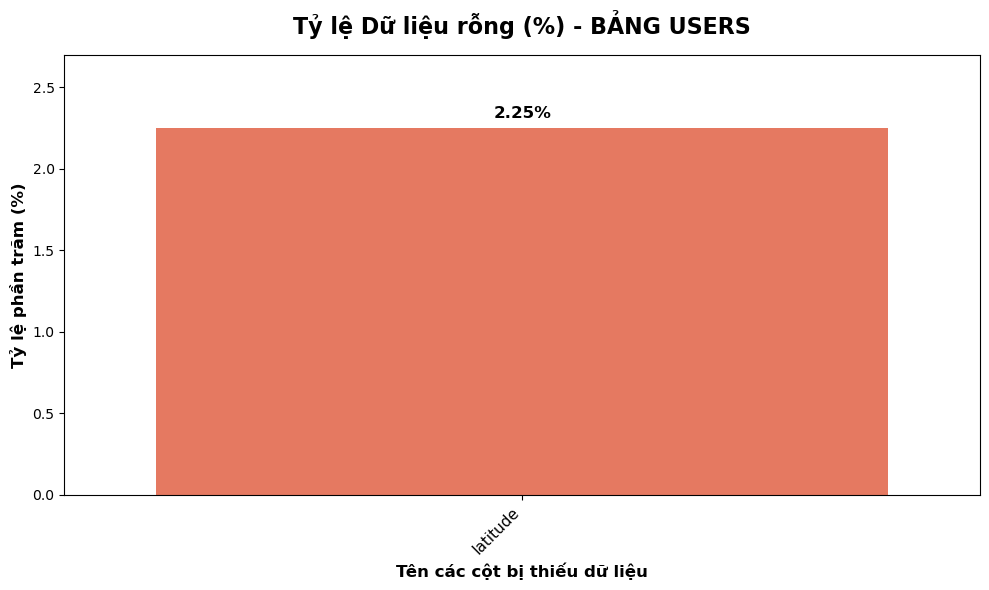

--------------------------------------------------------------------------------

 Đang xuất biểu đồ cho BẢNG TRANSACTIONS...


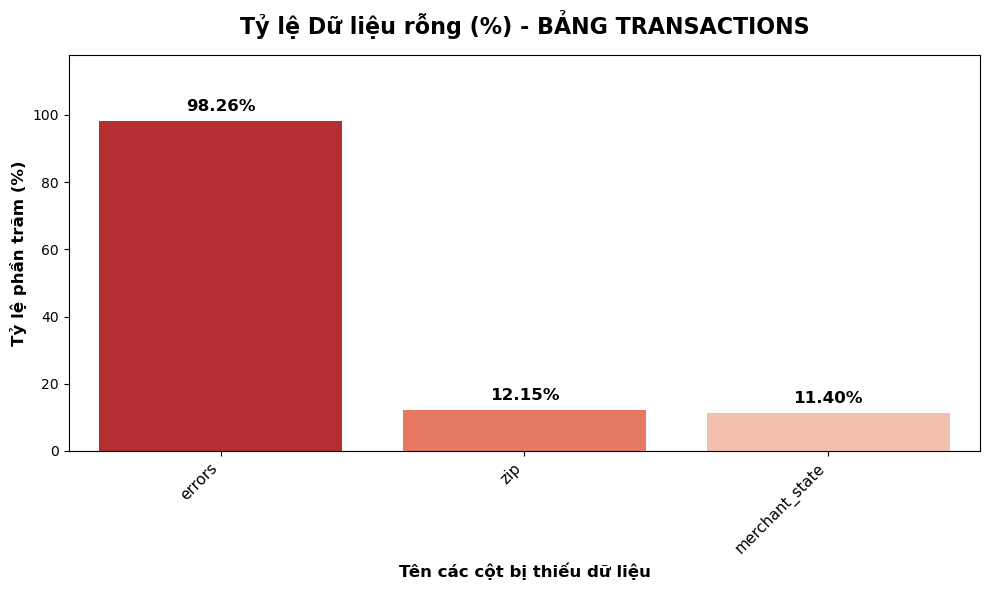

--------------------------------------------------------------------------------



In [12]:
# ==============================================================================
# TRỰC QUAN HÓA DỮ LIỆU THIẾU BẰNG BIỂU ĐỒ CỘT (BAR CHART)
# ==============================================================================
print(" BẮT ĐẦU VẼ BIỂU ĐỒ CỘT CHO CÁC BẢNG BỊ THIẾU DỮ LIỆU\n")

for name, df in datasets.items():
    # Tính tổng số dòng rỗng của từng cột
    missing_count = df.isnull().sum()
    
    # Chỉ lấy những cột thực sự có dữ liệu rỗng (> 0)
    missing_cols = missing_count[missing_count > 0]
    
    # Nếu có dữ liệu rỗng thì mới vẽ
    if not missing_cols.empty:
        print(f" Đang xuất biểu đồ cho BẢNG {name}...")
        
        # Tính tỷ lệ % và sắp xếp giảm dần cho biểu đồ đẹp mắt
        missing_percent = (missing_cols / len(df) * 100).sort_values(ascending=False)
        
        plt.figure(figsize=(10, 6))
        
        # Vẽ biểu đồ cột bằng Seaborn, dùng tông màu Đỏ cảnh báo (Reds_r)
        ax = sns.barplot(x=missing_percent.index, y=missing_percent.values, palette='Reds_r')
        
        # Trang trí nhãn dán, tiêu đề
        plt.title(f'Tỷ lệ Dữ liệu rỗng (%) - BẢNG {name}', fontsize=16, fontweight='bold', pad=15)
        plt.ylabel('Tỷ lệ phần trăm (%)', fontsize=12, fontweight='bold')
        plt.xlabel('Tên các cột bị thiếu dữ liệu', fontsize=12, fontweight='bold')
        plt.xticks(rotation=45, ha='right', fontsize=11)
        
        # Tăng giới hạn trục Y lên một chút để chữ không bị lẹm lên viền trên
        plt.ylim(0, max(missing_percent.values) * 1.2) 
        
        # Vòng lặp thần thánh: Ghi con số % lên chính giữa đỉnh của từng cột
        for p in ax.patches:
            ax.annotate(f"{p.get_height():.2f}%", 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', 
                        fontsize=12, fontweight='bold', color='black', 
                        xytext=(0, 5), textcoords='offset points')
        
        plt.tight_layout()
        plt.show()
        print("-" * 80 + "\n")

# XỬ LÝ MISSING VALUES CỘT LATITUDE ( BẢNG USERS )

In [13]:
# ==============================================================================
# XỬ LÝ MISSING VALUE VÀ DỌN DẸP DỮ LIỆU MỒ CÔI TOÀN HỆ THỐNG
# ==============================================================================

# ---------------------------------------------------------
# PHẦN 1: XÓA KHÁCH HÀNG BỊ RỖNG TỌA ĐỘ (BẢNG USERS)
# ---------------------------------------------------------
print(" BƯỚC 1: Xử lý 2.25% dữ liệu rỗng cột 'latitude' trong bảng USERS...\n")

# Lưu lại số dòng ban đầu để so sánh
so_dong_ban_dau = df_users.shape[0]

# Dùng lệnh dropna() nhắm mục tiêu chuẩn xác vào cột 'latitude'
df_users = df_users.dropna(subset=['latitude'])

# Tính toán số dòng đã bị xóa
so_dong_hien_tai = df_users.shape[0]
so_dong_da_xoa = so_dong_ban_dau - so_dong_hien_tai

print(f"   -> Đã xóa thành công {so_dong_da_xoa} dòng bị rỗng tọa độ.")
print(f"   -> Kích thước bảng USERS hiện tại: {so_dong_hien_tai:,} khách hàng hợp lệ.")
print(f"   -> Kiểm tra rỗng cột latitude hiện tại: {df_users['latitude'].isnull().sum()} ô.")
print("-" * 60)

# ---------------------------------------------------------
# PHẦN 2: DỌN DẸP DỮ LIỆU MỒ CÔI Ở CÁC BẢNG LIÊN QUAN
# ---------------------------------------------------------
print(" BƯỚC 2: Dọn dẹp thẻ và giao dịch mồ côi của các khách hàng đã xóa...\n")

# Lấy danh sách ID của các khách hàng hợp lệ (còn lại trong bảng USERS)
valid_client_ids = df_users['id'].unique()

# Dọn dẹp bảng CARDS
so_the_ban_dau = df_cards.shape[0]
df_cards = df_cards[df_cards['client_id'].isin(valid_client_ids)]
so_the_da_xoa = so_the_ban_dau - df_cards.shape[0]
print(f"    Bảng CARDS: Đã xóa {so_the_da_xoa} thẻ mồ côi. Còn lại {df_cards.shape[0]:,} thẻ.")

# Dọn dẹp bảng TRANSACTIONS
so_gd_ban_dau = df_transactions.shape[0]
df_transactions = df_transactions[df_transactions['client_id'].isin(valid_client_ids)]
so_gd_da_xoa = so_gd_ban_dau - df_transactions.shape[0]
print(f"    Bảng TRANSACTIONS: Đã xóa {so_gd_da_xoa:,} giao dịch mồ côi. Còn lại {df_transactions.shape[0]:,} giao dịch.")

print("=" * 60)
print(" QUÁ TRÌNH XỬ LÝ HOÀN TẤT: HỆ THỐNG DỮ LIỆU ĐÃ ĐỒNG BỘ 100%!")

 BƯỚC 1: Xử lý 2.25% dữ liệu rỗng cột 'latitude' trong bảng USERS...

   -> Đã xóa thành công 45 dòng bị rỗng tọa độ.
   -> Kích thước bảng USERS hiện tại: 1,955 khách hàng hợp lệ.
   -> Kiểm tra rỗng cột latitude hiện tại: 0 ô.
------------------------------------------------------------
 BƯỚC 2: Dọn dẹp thẻ và giao dịch mồ côi của các khách hàng đã xóa...

    Bảng CARDS: Đã xóa 139 thẻ mồ côi. Còn lại 6,007 thẻ.
    Bảng TRANSACTIONS: Đã xóa 3,700 giao dịch mồ côi. Còn lại 153,524 giao dịch.
 QUÁ TRÌNH XỬ LÝ HOÀN TẤT: HỆ THỐNG DỮ LIỆU ĐÃ ĐỒNG BỘ 100%!


# XỬ LÝ MISSING VALUE BẢNG TRANSACTIONS 

In [14]:
# ==========================================
# XỬ LÝ MISSING VALUE BẢNG TRANSACTIONS
# ==========================================
print(" Bắt đầu xử lý dữ liệu bảng TRANSACTIONS...\n")

# 1. Loại bỏ các giao dịch có lỗi (Chỉ giữ lại giao dịch thành công)
# Giao dịch thành công là giao dịch có cột 'errors' bị Rỗng (Null)
df_transactions = df_transactions[df_transactions['errors'].isnull()].copy()
print(f" Đã loại bỏ 2,738 giao dịch lỗi. Còn lại {df_transactions.shape[0]:,} giao dịch thành công.")

# 2. Loại bỏ các cột địa lý không cần thiết cho mô hình Clustering

cols_to_drop = ['merchant_state', 'zip', 'merchant_city', 'errors']
df_transactions = df_transactions.drop(columns=cols_to_drop)
print(f" Đã xóa các cột không cần thiết: {cols_to_drop}")

# 3. Kiểm tra lại lần cuối
print("\n Kiểm tra Missing Value sau khi xử lý:")
print(df_transactions.isnull().sum())

print("-" * 50)
print(f" Kích thước bảng TRANSACTIONS hiện tại: {df_transactions.shape[0]:,} dòng và {df_transactions.shape[1]} cột.")

 Bắt đầu xử lý dữ liệu bảng TRANSACTIONS...

 Đã loại bỏ 2,738 giao dịch lỗi. Còn lại 150,879 giao dịch thành công.
 Đã xóa các cột không cần thiết: ['merchant_state', 'zip', 'merchant_city', 'errors']

 Kiểm tra Missing Value sau khi xử lý:
id             0
date           0
client_id      0
card_id        0
amount         0
use_chip       0
merchant_id    0
mcc            0
dtype: int64
--------------------------------------------------
 Kích thước bảng TRANSACTIONS hiện tại: 150,879 dòng và 8 cột.


# KIỂM TRA OUTLIERS CỦA CÁC BẢNG DỮ LIỆU 


 BẮT ĐẦU VẼ BOX PLOT KIỂM TRA OUTLIERS

 Đang xuất biểu đồ cho BẢNG USERS...


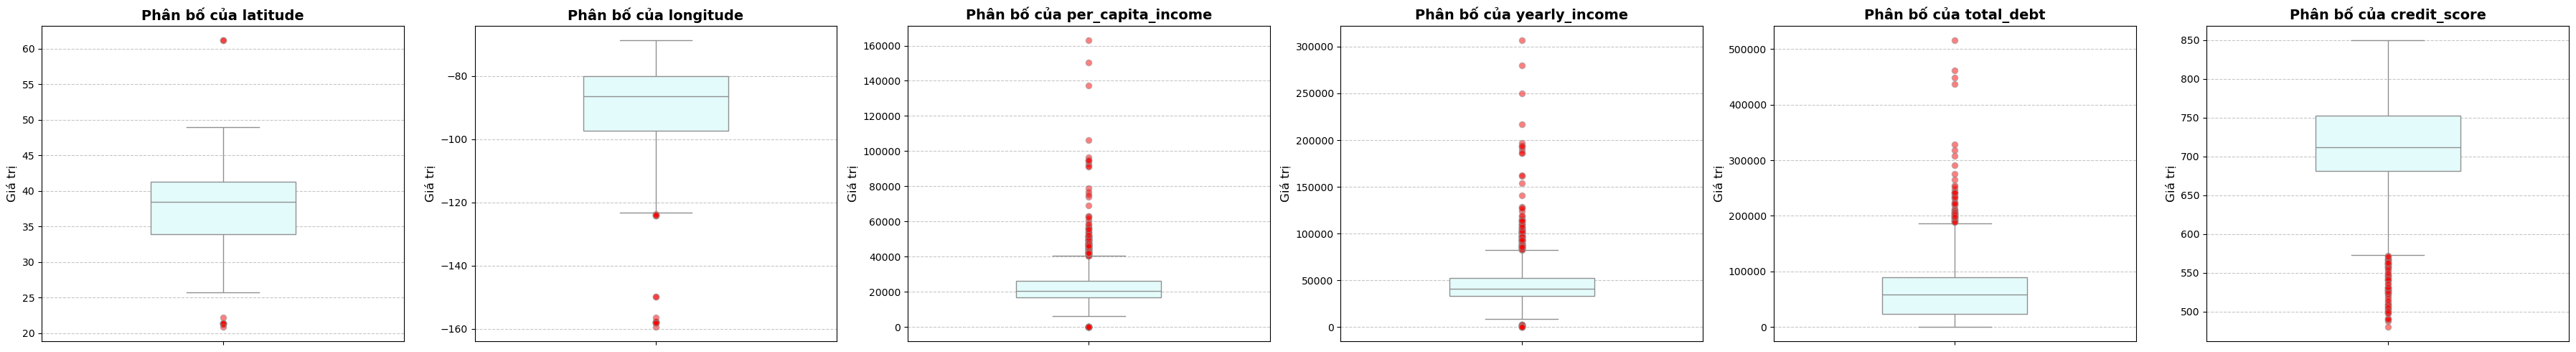

--------------------------------------------------------------------------------

 Đang xuất biểu đồ cho BẢNG CARDS...


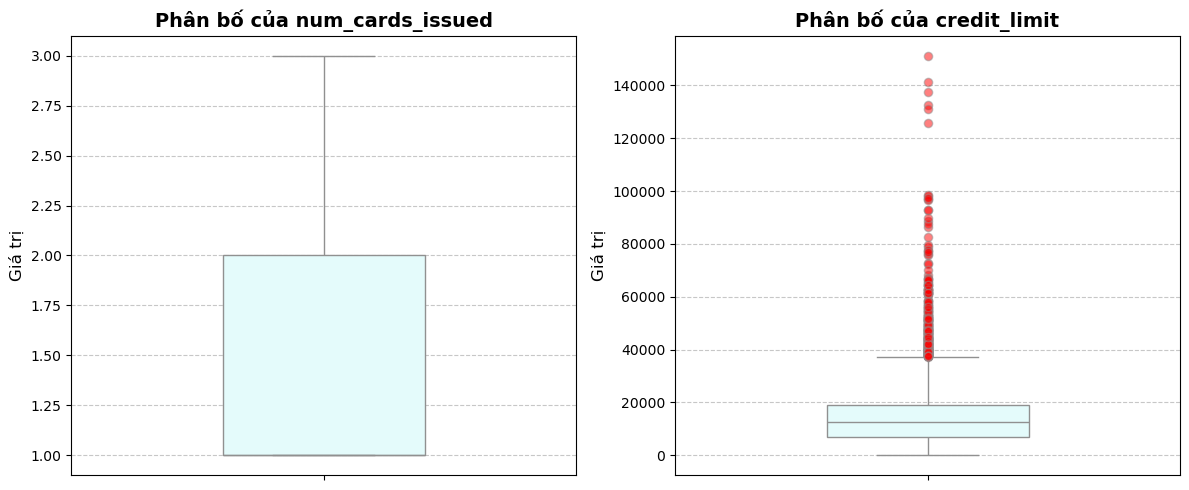

--------------------------------------------------------------------------------

 Đang xuất biểu đồ cho BẢNG TRANSACTIONS...


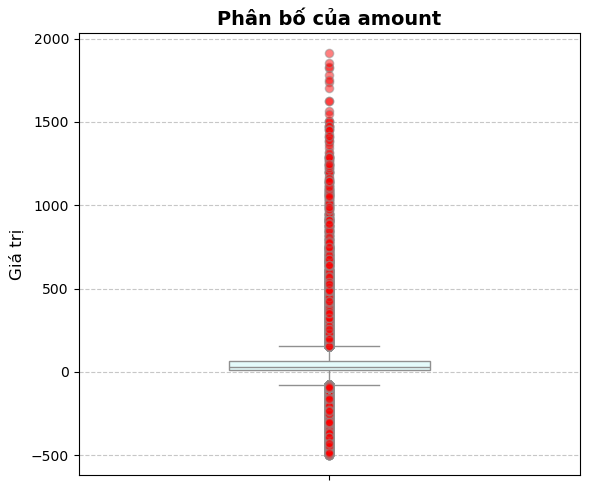

--------------------------------------------------------------------------------



In [16]:
# ==============================================================================
# TRỰC QUAN HÓA DỮ LIỆU NGOẠI LAI (OUTLIERS) BẰNG BOX PLOT
# ==============================================================================

print(" BẮT ĐẦU VẼ BOX PLOT KIỂM TRA OUTLIERS\n")

# Danh sách các cột "Định danh" hoặc "Thời gian" cần bỏ qua
exclude_cols = ['id', 'client_id', 'card_id', 'merchant_id', 'mcc', 'mcc_id', 'zip', 
                'birth_year', 'birth_month', 'current_age', 'retirement_age', 'num_credit_cards', 
                'cvv', 'year_pin_last_changed', 'card_number']

for name, df in datasets.items():
    # 1. Lọc ra các cột là số (int, float)
    num_cols = df.select_dtypes(include=[np.number]).columns
    
    # 2. Bỏ đi các cột nằm trong danh sách exclude_cols
    plot_cols = [col for col in num_cols if col not in exclude_cols]
    
    # Nếu bảng không có cột nào hợp lệ để vẽ thì bỏ qua
    if not plot_cols:
        continue
        
    print(f" Đang xuất biểu đồ cho BẢNG {name}...")
    
    # Thiết lập kích thước biểu đồ động dựa trên số lượng cột cần vẽ
    n_cols = len(plot_cols)
    fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 5))
    
    # Đảm bảo axes luôn là một list có thể lặp được (trường hợp chỉ có 1 biểu đồ)
    if n_cols == 1:
        axes = [axes]
        
    # Lặp qua từng cột để vẽ Box Plot
    for i, col in enumerate(plot_cols):
        # flierprops dùng để làm nổi bật các điểm Outliers thành các chấm đỏ
        sns.boxplot(y=df[col], ax=axes[i], color='lightcyan', width=0.4,
                    flierprops=dict(markerfacecolor='red', marker='o', markersize=6, alpha=0.5))
        
        axes[i].set_title(f'Phân bố của {col}', fontsize=14, fontweight='bold')
        axes[i].set_ylabel('Giá trị', fontsize=12)
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
    print("-" * 80 + "\n")

# STEP 4: FEATURE ENGINEERING

# GỘP DỮ LIỆU THÀNH BẢNG TỔNG HỢP 

In [19]:
# ==============================================================================
# BƯỚC CHUYỂN GIAO: TÍNH TOÁN RFM - GỘP SIÊU BẢNG - LƯU CHECKPOINT
# ==============================================================================
import pandas as pd
import datetime as dt

print(" BẮT ĐẦU BƯỚC CHUYỂN GIAO: TÍNH RFM & TẠO SIÊU BẢNG\n")

# 1. LỌC GIAO DỊCH HỢP LỆ (Loại bỏ các giao dịch có số tiền âm / hoàn tiền)
print(" 1. Lọc giao dịch hợp lệ (amount > 0)...")
df_trans_clean = df_transactions[df_transactions['amount'] > 0].copy()

# 2. TÍNH TOÁN BỘ CHỈ SỐ RFM
print(" 2. Đang tính toán bộ chỉ số RFM (Recency, Frequency, Monetary)...")
# Lấy mốc thời gian là 1 ngày sau giao dịch cuối cùng trong toàn hệ thống
current_date = df_trans_clean['date'].max() + dt.timedelta(days=1)

# Nhào nặn dữ liệu
rfm_table = df_trans_clean.groupby('client_id').agg({
    'date': lambda x: (current_date - x.max()).days,  # R: Số ngày từ lần quẹt cuối
    'id': 'count',                                    # F: Tổng số lần quẹt thẻ
    'amount': 'sum'                                   # M: Tổng số tiền đã tiêu
}).reset_index()

# Đổi tên cho chuẩn Data Science
rfm_table.rename(columns={'date': 'Recency', 'id': 'Frequency', 'amount': 'Monetary'}, inplace=True)

# 3. GỘP THÀNH SIÊU BẢNG (MASTER TABLE)
print(" 3. Đang hợp nhất với bảng USERS để tạo df_master...")
# Dùng how='inner' để tự động loại bỏ bất kỳ khách hàng nào không khớp giữa 2 bảng
df_master = pd.merge(rfm_table, 
                     df_users[['id', 'current_age', 'yearly_income', 'credit_score', 'total_debt']], 
                     left_on='client_id', right_on='id', 
                     how='inner')

# Bỏ cột 'id' bị thừa sau khi merge
df_master.drop(columns=['id'], inplace=True)

print(f" Hợp nhất thành công! Siêu bảng df_master có {df_master.shape[0]:,} khách hàng.")

# 4. TẠO ĐIỂM LƯU TRỮ (CHECKPOINT) BẰNG PICKLE
print("\n 4. Đang đóng băng dữ liệu...")
# Sửa lại đường dẫn: Thêm ../ để lùi ra ngoài 1 thư mục
checkpoint_path = '../dataset/customer_master_clean.pkl'

# Chạy lại lệnh lưu
df_master.to_pickle(checkpoint_path)

print("-" * 60)
print(f" ĐÃ ĐÓNG BĂNG DỮ LIỆU THÀNH CÔNG VÀO: {checkpoint_path}")


 BẮT ĐẦU BƯỚC CHUYỂN GIAO: TÍNH RFM & TẠO SIÊU BẢNG

 1. Lọc giao dịch hợp lệ (amount > 0)...
 2. Đang tính toán bộ chỉ số RFM (Recency, Frequency, Monetary)...
 3. Đang hợp nhất với bảng USERS để tạo df_master...
 Hợp nhất thành công! Siêu bảng df_master có 297 khách hàng.

 4. Đang đóng băng dữ liệu...
------------------------------------------------------------
 ĐÃ ĐÓNG BĂNG DỮ LIỆU THÀNH CÔNG VÀO: ../dataset/customer_master_clean.pkl


# Xuất bảng dữ liệu ra file excel 

In [22]:
# ==============================================================================
# XUẤT SIÊU BẢNG (MASTER TABLE) RA FILE EXCEL ĐỂ KIỂM TRA
# ==============================================================================
import os

# 1. Định nghĩa đường dẫn lưu file (lưu vào folder output cho gọn gàng)
excel_output_path = '../output/df_master.xlsx'

# 2. Tự động tạo thư mục 'output' nếu nó chưa tồn tại
os.makedirs('../output', exist_ok=True)

print(" Đang bắt đầu quá trình xuất dữ liệu ra Excel...")

# 3. Thực hiện xuất file
# Lưu ý: Bạn có thể cần cài thêm thư viện openpyxl nếu máy báo lỗi (pip install openpyxl)
try:
    df_master.to_excel(excel_output_path, index=False, engine='openpyxl')
    print(f" Đã xuất file Excel thành công tại: {excel_output_path}")
    print(f" Bạn có thể mở thư mục 'output' để kiểm tra file.")
except Exception as e:
    print(f" Có lỗi xảy ra khi xuất file: {e}")

print("-" * 60)

 Đang bắt đầu quá trình xuất dữ liệu ra Excel...
 Đã xuất file Excel thành công tại: ../output/df_master.xlsx
 Bạn có thể mở thư mục 'output' để kiểm tra file.
------------------------------------------------------------


# KIỂM TRA TỔNG QUAN DỮ LIỆU TỔNG HỢP 

In [23]:
df_master.head()

,client_id,Recency,Frequency,Monetary,current_age,yearly_income,credit_score,total_debt
0,0,1,601,35520.89,33,59613,763,36199
1,1,3,422,15367.13,43,45360,704,14587
2,2,4,469,15687.60,48,27447,673,80850
3,3,4,302,14334.53,49,27943,681,18693
4,4,3,667,30414.66,54,76431,716,115362


In [25]:
df_master.tail()

,client_id,Recency,Frequency,Monetary,current_age,yearly_income,credit_score,total_debt
292,490,2,973,78304.16,86,33426,699,1852
293,491,6,145,8852.68,40,27013,651,58806
294,494,3,445,19166.34,39,56347,779,32530
295,496,3,249,12785.30,47,36319,730,44737
296,497,3,526,29030.25,63,52380,850,8764


In [26]:
df_master.sample

<bound method NDFrame.sample of      client_id  Recency  Frequency  Monetary  current_age  yearly_income  \
0            0        1        601  35520.89           33          59613   
1            1        3        422  15367.13           43          45360   
2            2        4        469  15687.60           48          27447   
3            3        4        302  14334.53           49          27943   
4            4        3        667  30414.66           54          76431   
..         ...      ...        ...       ...          ...            ...   
292        490        2        973  78304.16           86          33426   
293        491        6        145   8852.68           40          27013   
294        494        3        445  19166.34           39          56347   
295        496        3        249  12785.30           47          36319   
296        497        3        526  29030.25           63          52380   

     credit_score  total_debt  
0             763      

In [30]:
df_master.shape

(297, 8)

Sau khi gộp 4 bảng riêng lẻ thì chúng ta được bộ dữ liệu tổng hợp với có 297 dòng tượng trưng cho 297 khác hàng và 8 cột đặc trưng.

In [27]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   client_id      297 non-null    int64  
 1   Recency        297 non-null    int64  
 2   Frequency      297 non-null    int64  
 3   Monetary       297 non-null    float64
 4   current_age    297 non-null    int64  
 5   yearly_income  297 non-null    int64  
 6   credit_score   297 non-null    int64  
 7   total_debt     297 non-null    int64  
dtypes: float64(1), int64(7)
memory usage: 18.7 KB


In [28]:
df_master.describe()

,client_id,Recency,Frequency,Monetary,current_age,yearly_income,credit_score,total_debt
count,297.000000,297.000000,297.000000,297.00000,297.000000,297.000000,297.000000,297.000000
mean,240.936027,8.050505,480.838384,24678.44633,52.181818,42970.838384,718.164983,54077.299663
std,146.177093,59.620768,234.597616,15243.97230,15.176015,19007.794953,58.094312,44718.545235
min,0.000000,1.000000,37.000000,2453.73000,24.000000,8526.000000,498.000000,0.000000
25%,118.000000,1.000000,319.000000,14351.31000,41.000000,31177.000000,686.000000,17453.000000
50%,230.000000,2.000000,435.000000,20772.67000,49.000000,38318.000000,716.000000,50734.000000
75%,369.000000,4.000000,581.000000,30414.66000,61.000000,50258.000000,759.000000,78801.000000
max,497.000000,825.000000,1553.000000,135945.20000,99.000000,193768.000000,850.000000,231619.000000


In [29]:
df_master.isnull().sum()

client_id        0
Recency          0
Frequency        0
Monetary         0
current_age      0
yearly_income    0
credit_score     0
total_debt       0
dtype: int64

# Kiểm tra Outliers của bảng dữ liệu 

 ĐANG VẼ BOX PLOT SĂN 'CÁ MẬP' (BẢN PHÓNG TO, 2 HÌNH/HÀNG)...



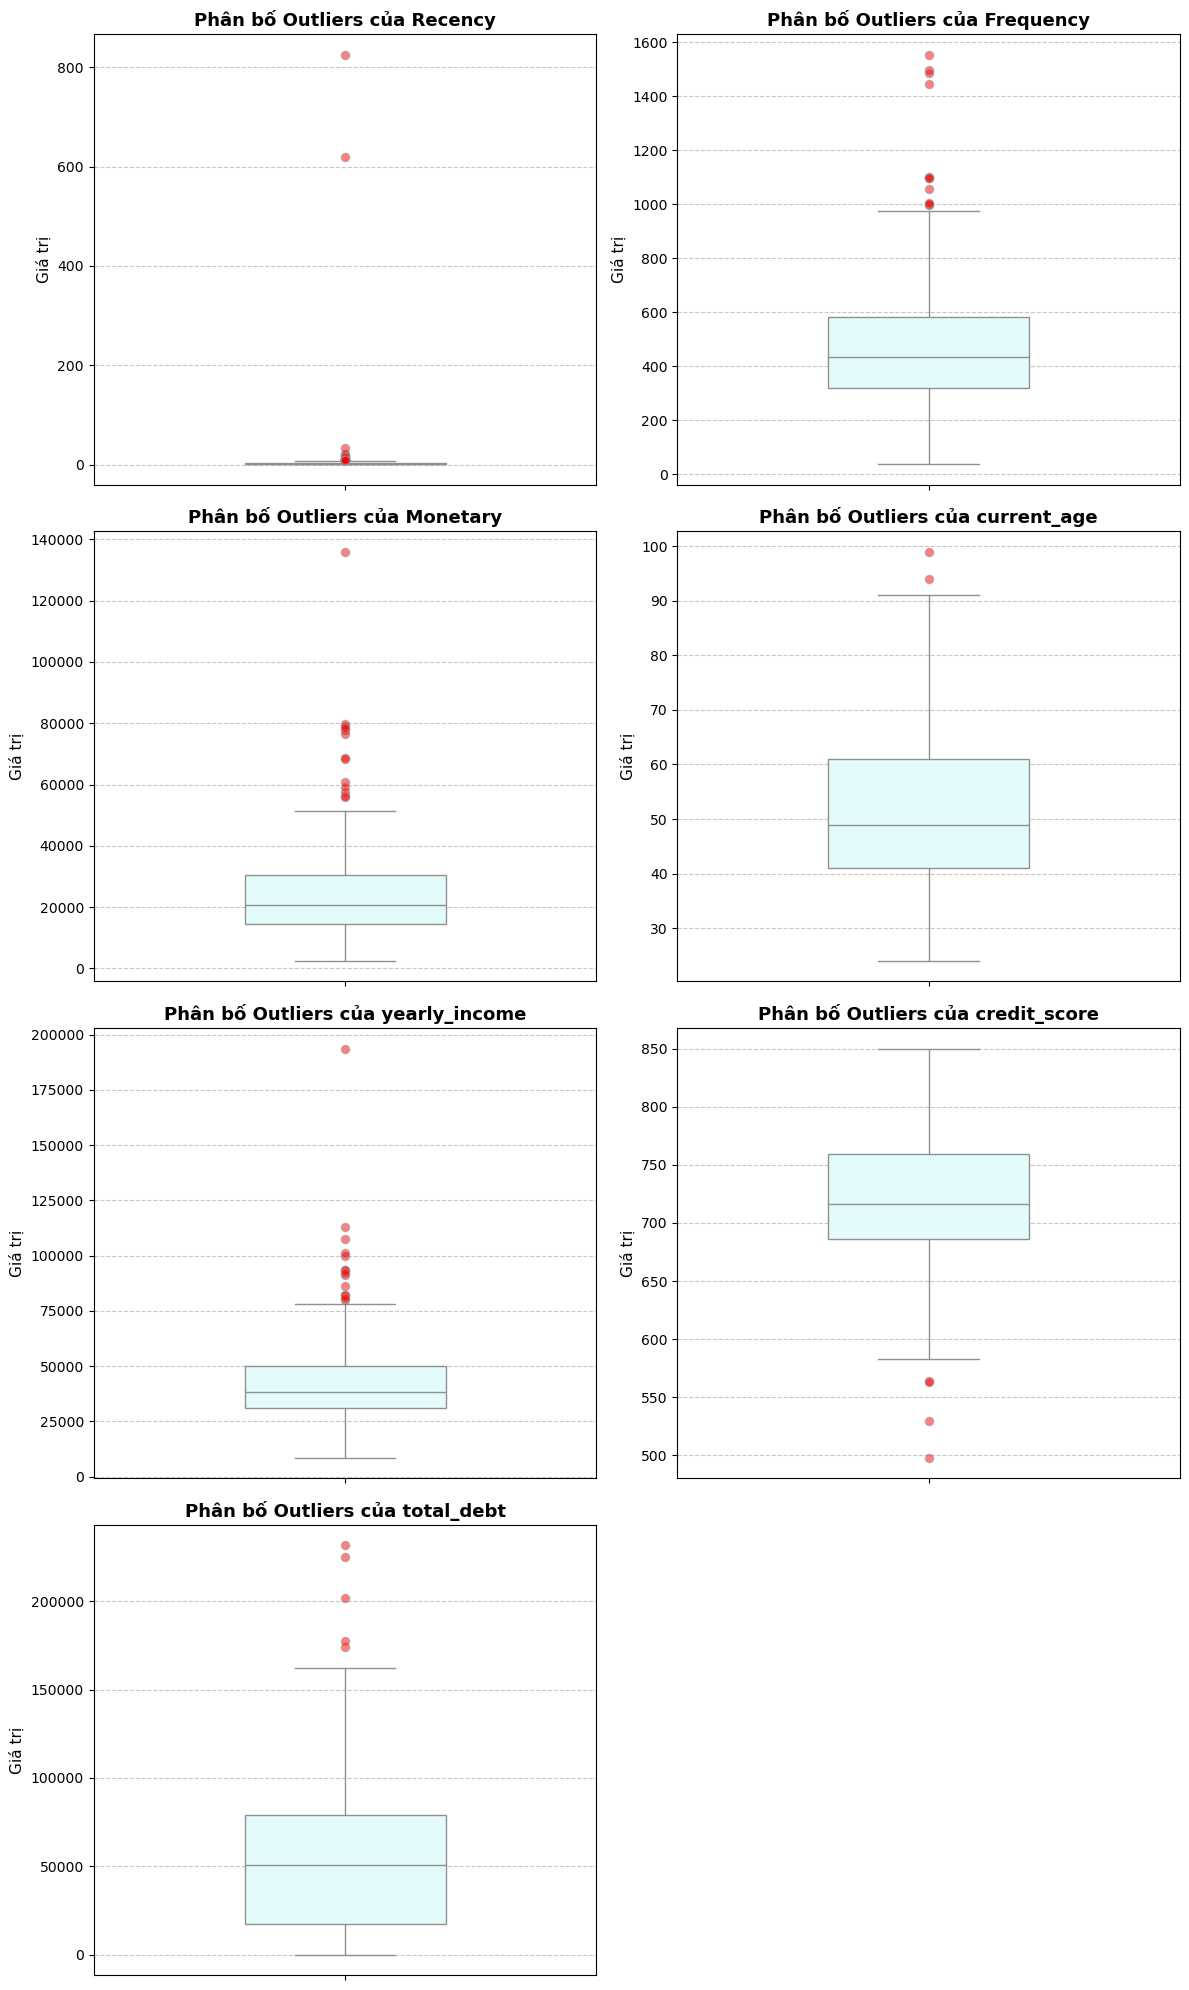

--------------------------------------------------------------------------------
 Đã vẽ xong bản phóng to. Bạn hãy soi kỹ các chấm đỏ ở cột Monetary và Frequency nhé!


In [32]:
# ==============================================================================
# BƯỚC 3 (TIẾP THEO): KIỂM TRA OUTLIERS TRÊN SIÊU BẢNG (BẢN TỐT GIÁO CHO BẮT)
# Cấu hình: Mỗi hàng chỉ vẽ 2 hình để dễ quan sát
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print(" ĐANG VẼ BOX PLOT SĂN 'CÁ MẬP' (BẢN PHÓNG TO, 2 HÌNH/HÀNG)...\n")

# 1. Lấy các cột là số và loại bỏ cột định danh client_id
num_cols = df_master.select_dtypes(include=[np.number]).columns
plot_cols = [col for col in num_cols if col != 'client_id']

# 2. CẤU HÌNH LAYOUT: MỖI HÀNG CÓ 2 HÌNH
plots_per_row = 2
n_cols_to_plot = len(plot_cols)

# Tự động tính toán số hàng cần thiết dựa trên 2 cột/hàng
# Công thức: (số_cột + 1) chia lấy nguyên cho 2
n_rows = (n_cols_to_plot + plots_per_row - 1) // plots_per_row

# Thiết lập kích thước khung hình tổng thể (figsize)
# Chiều rộng 12 inch (đủ cho 2 hình), chiều cao tăng lên 5 inch * số hàng (để hình to rõ)
fig, axes = plt.subplots(nrows=n_rows, ncols=plots_per_row, figsize=(12, 5 * n_rows))

# Trải phẳng mảng axes để dễ lặp qua (xử lý cả trường hợp axes là mảng 2D hoặc 1D)
if n_rows > 1:
    axes = axes.flatten()
elif n_cols_to_plot == 1:
    axes = [axes] # Nếu chỉ có 1 hình thì đưa vào list để lặp được

# 3. VÒNG LẶP VẼ BIỂU ĐỒ
for i, col in enumerate(plot_cols):
    # flierprops dùng để làm nổi bật các điểm Outliers thành các chấm đỏ to rõ hơn
    sns.boxplot(y=df_master[col], ax=axes[i], color='lightcyan', width=0.4,
                flierprops=dict(markerfacecolor='red', marker='o', markersize=6, alpha=0.5))
    
    # Định dạng tiêu đề và nhãn
    axes[i].set_title(f'Phân bố Outliers của {col}', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Giá trị', fontsize=11)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# 4. XÓA CÁC KHUNG BIỂU ĐỒ THỪA (nếu số lượng cột là số lẻ)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Tự động điều chỉnh khoảng cách giữa các hình
plt.tight_layout()
plt.show()

print("-" * 80)
print(" Đã vẽ xong bản phóng to. Bạn hãy soi kỹ các chấm đỏ ở cột Monetary và Frequency nhé!")